# README


**Project Title:**  

**Tutorial section: TT6L**

**Group04**

<div align="left">
    
| | Student ID     | Student Name                | Contribution | 
|--:|:-------------|:----------------------------|-------------:|
| 1 | Student_ID1  | Student_Name1               | 30%          | 
| 2 | Student_ID2  | Student_Name1               | 20%          | 
| 3 | Student_ID3  | Student_Name1               | 10%          | 
| 4 | Student_ID4  | Student_Name1               | 40%          | 

</div>

Note: Marks may vary among group members based on individual contributions. Ensure all members agree on the contribution percentages listed here.

**YouTube link:**  
Please note that the examiner will not notify you if your video link is unavailable, inaccessible, or incorrectly provided. It is the responsibility of the group to ensure that the video link is fully functional and accessible at the time of assessment. Failure to provide a valid and working link will result in a score of zero (0) marks for the presentation component.

**Dataset Title:**  
**Source & Link:** (e.g., Kaggle / UCI / Data.gov / Google Dataset Search — provide the dataset page URL)  
**Download instructions:** If the dataset requires sign-in (e.g., Kaggle), document the exact steps here      
**Brief Description (2–4 sentences):**   

**How to Run (if required, 1–3 steps):**  
  Instructions to run the notebook, including how to place the dataset files.    
  

## 1. Introduction & Problem Statement
- What is the main objective of this analysis?
- What key questions/hypotheses will you explore?
- Why is this dataset suitable for these questions?
- All citations must be in listed in APA style.


In [58]:
import numpy as np
import pandas as pd
from numpy import nan as NA
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

## 2. Data Source & Understanding
- **Description:** Features/columns, size, time span, units
- **Limitations:** Coverage, missingness, sampling bias, known caveats


## 3. Initial Data Checks
- Shape, columns, dtypes
- Sample rows (head/tail)
- Basic summary statistics


In [59]:
netflix = pd.read_csv('netflix_titles.csv')
netflix.shape

(8807, 12)

In [60]:
netflix.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [61]:
netflix.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [62]:
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [63]:
netflix.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [64]:
display(netflix.describe())

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [65]:
display(netflix.describe(include=['object', 'string']))

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


## 4. Data Cleaning & Preprocessing
- Handle missing values (strategy and justification)
- Fix types (dates, categoricals, numerics)
- Remove/flag outliers
- Feature engineering (document purpose)
- Keep transformations transparent and reproducible


### Handle missing data

In [66]:
null_rows = netflix.isnull().any(axis=1)
netflix[null_rows] #shows 3475 rows with missing data


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8795,s8796,TV Show,Yu-Gi-Oh! Arc-V,NaN,"Mike Liscio, Emily Bauer, Billy Bob Thompson, ...","Japan, Canada","May 1, 2018",2015,TV-Y7,2 Seasons,"Anime Series, Kids' TV",Now that he's discovered the Pendulum Summonin...
8796,s8797,TV Show,Yunus Emre,NaN,"Gökhan Atalay, Payidar Tüfekçioglu, Baran Akbu...",Turkey,"January 17, 2017",2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas","During the Mongol invasions, Yunus Emre leaves..."
8797,s8798,TV Show,Zak Storm,NaN,"Michael Johnston, Jessica Gee-George, Christin...","United States, France, South Korea, Indonesia","September 13, 2018",2016,TV-Y7,3 Seasons,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...
8800,s8801,TV Show,Zindagi Gulzar Hai,NaN,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,"December 15, 2016",2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre..."


In [67]:
netflix[null_rows].shape

(3475, 12)

In [68]:
netflix.isnull().sum() #check null value total

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [69]:
def null_values(netflix):
    
    #Fill director, cast and country with null value with 'Unknown'
    netflix['director'] = netflix['director'].fillna('Unknown')
    netflix['cast'] = netflix['cast'].fillna('Unknown')
    netflix['country'] = netflix['country'].fillna('Unknown')

    #Drop null value of date_added and duration
    netflix = netflix.dropna(subset = ['date_added'])
    netflix = netflix.dropna(subset = ['duration'])

    #Replace rating with most frequent category
    netflix["rating"] =  netflix["rating"].fillna(netflix["rating"].mode()[0]) 

    return netflix

#### Check on Data Type

In [70]:
netflix.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [71]:
def fix_datatypes(netflix):
    #Convert 'date_added' to datetime instead of string
    netflix['date_added'] = netflix['date_added'].str.strip() # to clean the extra spaces
    netflix['date_added'] = pd.to_datetime(netflix['date_added'])

    return netflix

#### Check Duplicated Data

In [72]:
netflix.duplicated().sum()

np.int64(0)

#### Clean Text

In [73]:
def clean_text(netflix):

    netflix['type'] = netflix['type'].str.strip().str.upper()
    
    #Only one country per show
    netflix['country'] = netflix['country'].str.split(',').str[0]

    return netflix

#### Divide Duration into it type and value

In [74]:
def divide_duration(netflix):

    #Divide duration into type and value
    netflix[['duration_value', 'duration_type']] = netflix['duration'].str.split(' ', n=1, expand=True)
    netflix['duration_value'] = netflix['duration_value'].astype(int)

    return netflix

### Create Cleaning Pipepline

In [75]:
clean_netflix = (
    netflix
    .pipe(null_values)
    .pipe(fix_datatypes)
    .pipe(clean_text)
    .pipe(divide_duration)

)

In [76]:

clean_netflix.to_csv('netflix_cleaned.csv', index = False)

## 5. Exploratory Data Analysis (EDA)
- Univariate distributions
- Bivariate relationships
- Correlations/associations
- Well-labeled, readable plots with units where applicable


## Univariate Distributions

### Type Distribution: Number of Movies vs TV Shows

Text(0.5, 1.0, 'Distribution of Content Type')

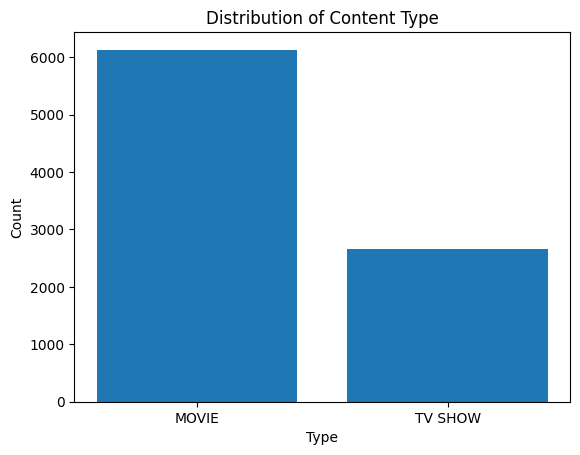

In [77]:
movie_type = ["MOVIE", "TV SHOW"]

netflix_cleaned = pd.read_csv('netflix_cleaned.csv')
plt.bar(movie_type, netflix_cleaned["type"].value_counts())

# set x/y labels and plot title
plt.xlabel("Type")
plt.ylabel("Count")
plt.title("Distribution of Content Type")

The bar chart illustrates the distribution of content types in the Netflix cleaned dataset by combapring the number of Movies and TV Shows. The cart shows that MOvies significantly outnumber TV SHows. The number of Mocies is more that twice the number of TV Shows indicating a clear difference in content distribution. This suggests that Netflix's content is primarily focus on movies rather than TV Shows. 

### Release Year Distribution: How many titles were released each year ?

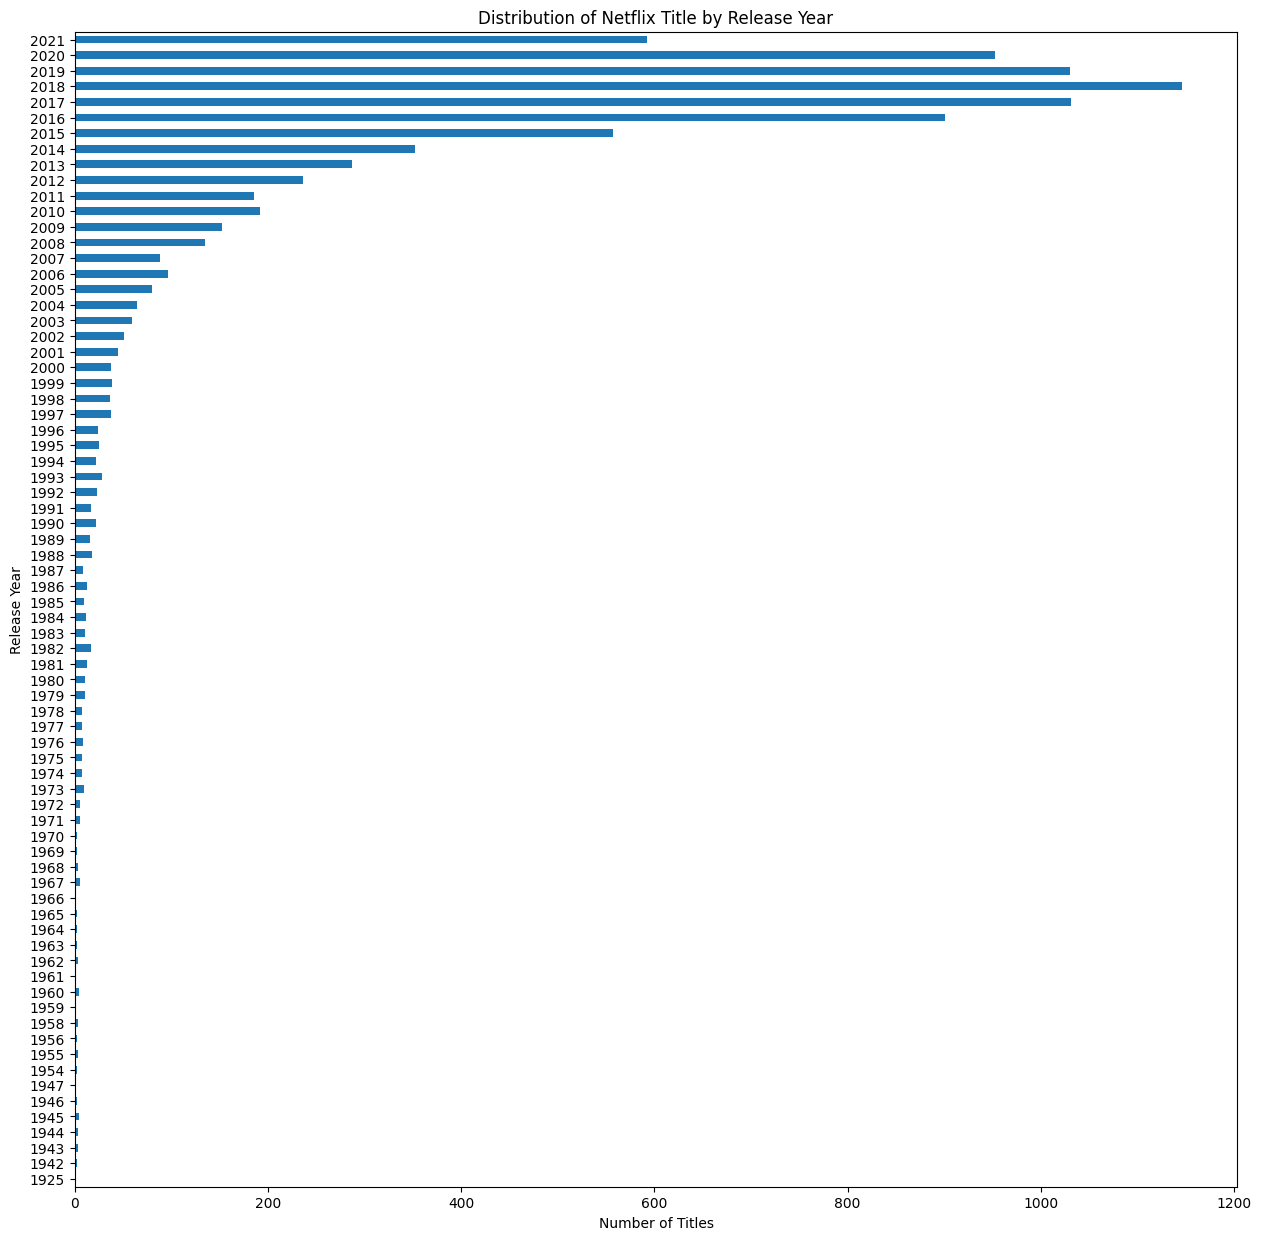

In [78]:
release_year_dist = netflix_cleaned['release_year'].value_counts().sort_index()
release_year_dist.plot(
    kind='barh',
    figsize=(15,15)
)

plt.title('Distribution of Netflix Title by Release Year')
plt.xlabel('Number of Titles')
plt.ylabel('Release Year')
plt.show()


The horizontal bar chart illustrates the number of Netflix titles released each year, showing how content production has changed over time. The number of titles released each year is relatively low in the earlier decades but increases over time. A sharp rise can be observed around 2000s, with the highest number of releases occuring in 2018. After the peak, the number of releases decreases slightly in the most recent year. This suggests that Netflix catalog is dominated by more recently released content. The rapid increases in release in 2000s reflects the expansion of content production and acquisition, while slightly decline in the latest years may be due to the dataset's collection period or fewer recent titles being included.

### Country Distribution: Top countries producing content

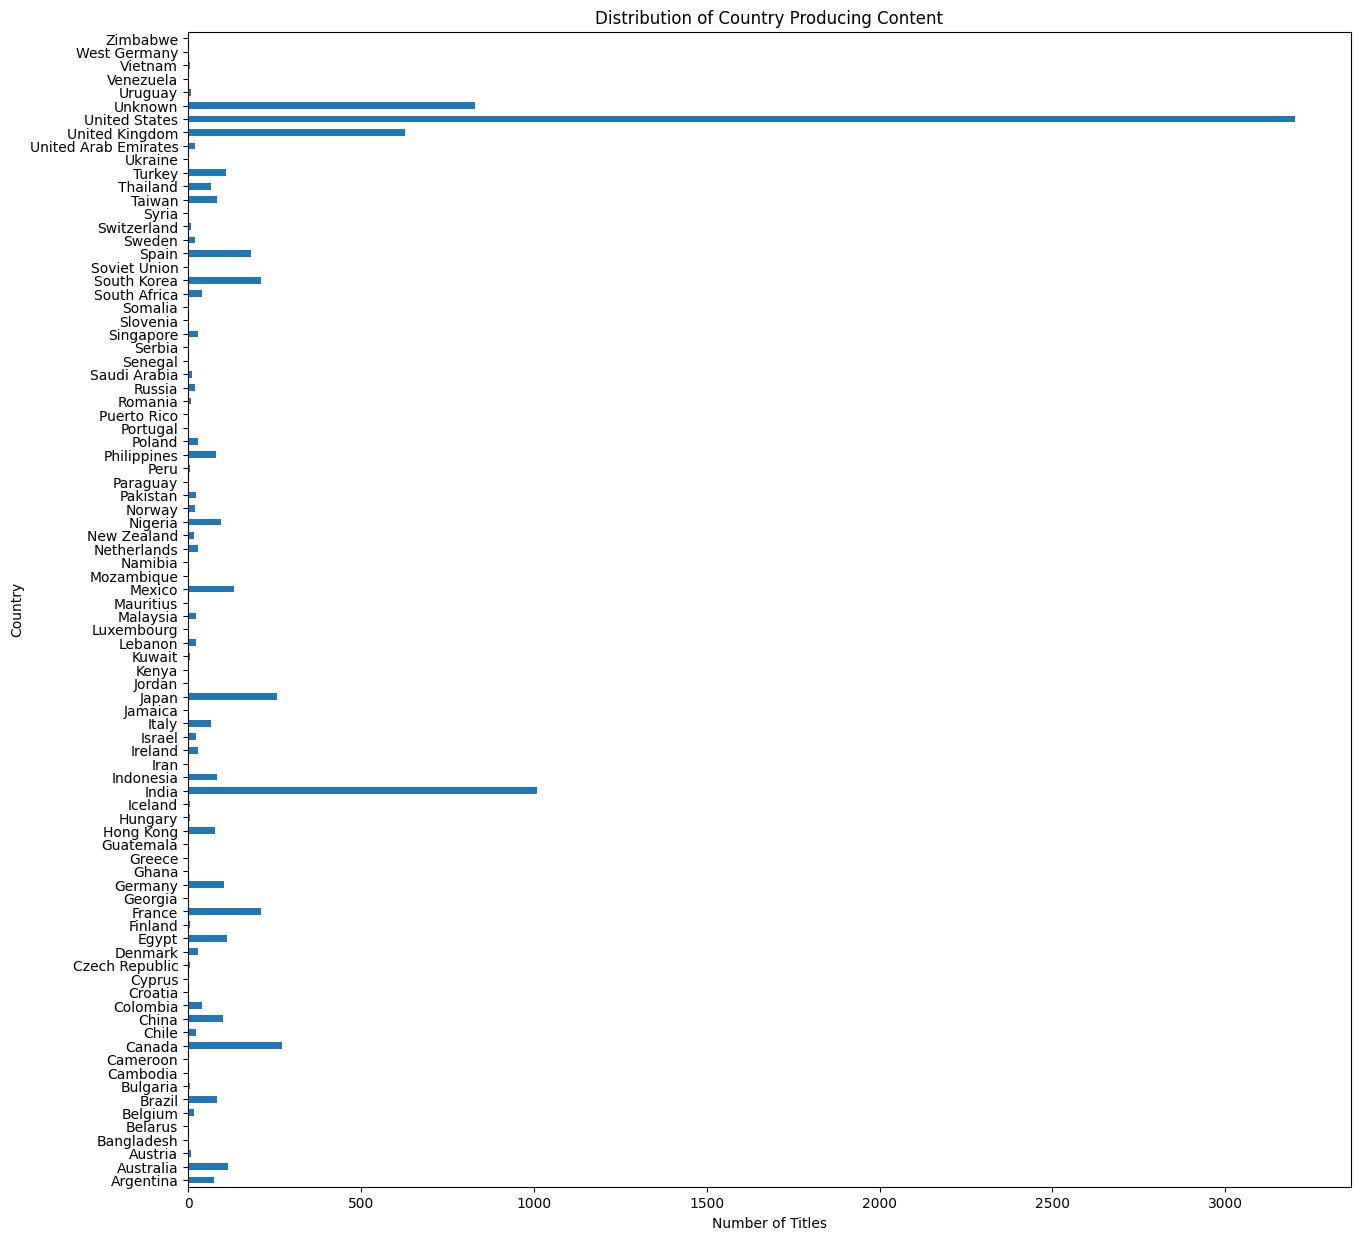

In [ ]:
country_dist = netflix_cleaned['country'].value_counts().sort_index()
country_dist.plot(
    kind='barh',
    figsize=(15,15)
)

plt.title('Distribution of Country Producing Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

The bar char represents the top countries that produce the most content in the Netflix dataset. The United States has the highest number of titles, making it the largest content-producing country in the dataset. Second is India followed by countries such as the United Kingdom, Canada and Japan. Thwre is a noticeable gap between the United States and the other countries. This indicate that Netflix content is heavily dominated by production from the United States, while other countries such as India and United Kingdom also make significant contributions. 

## Bivariate Relationship

### Country vs Type : Which countries produce more movies or TV shows?

<function matplotlib.pyplot.show(close=None, block=None)>

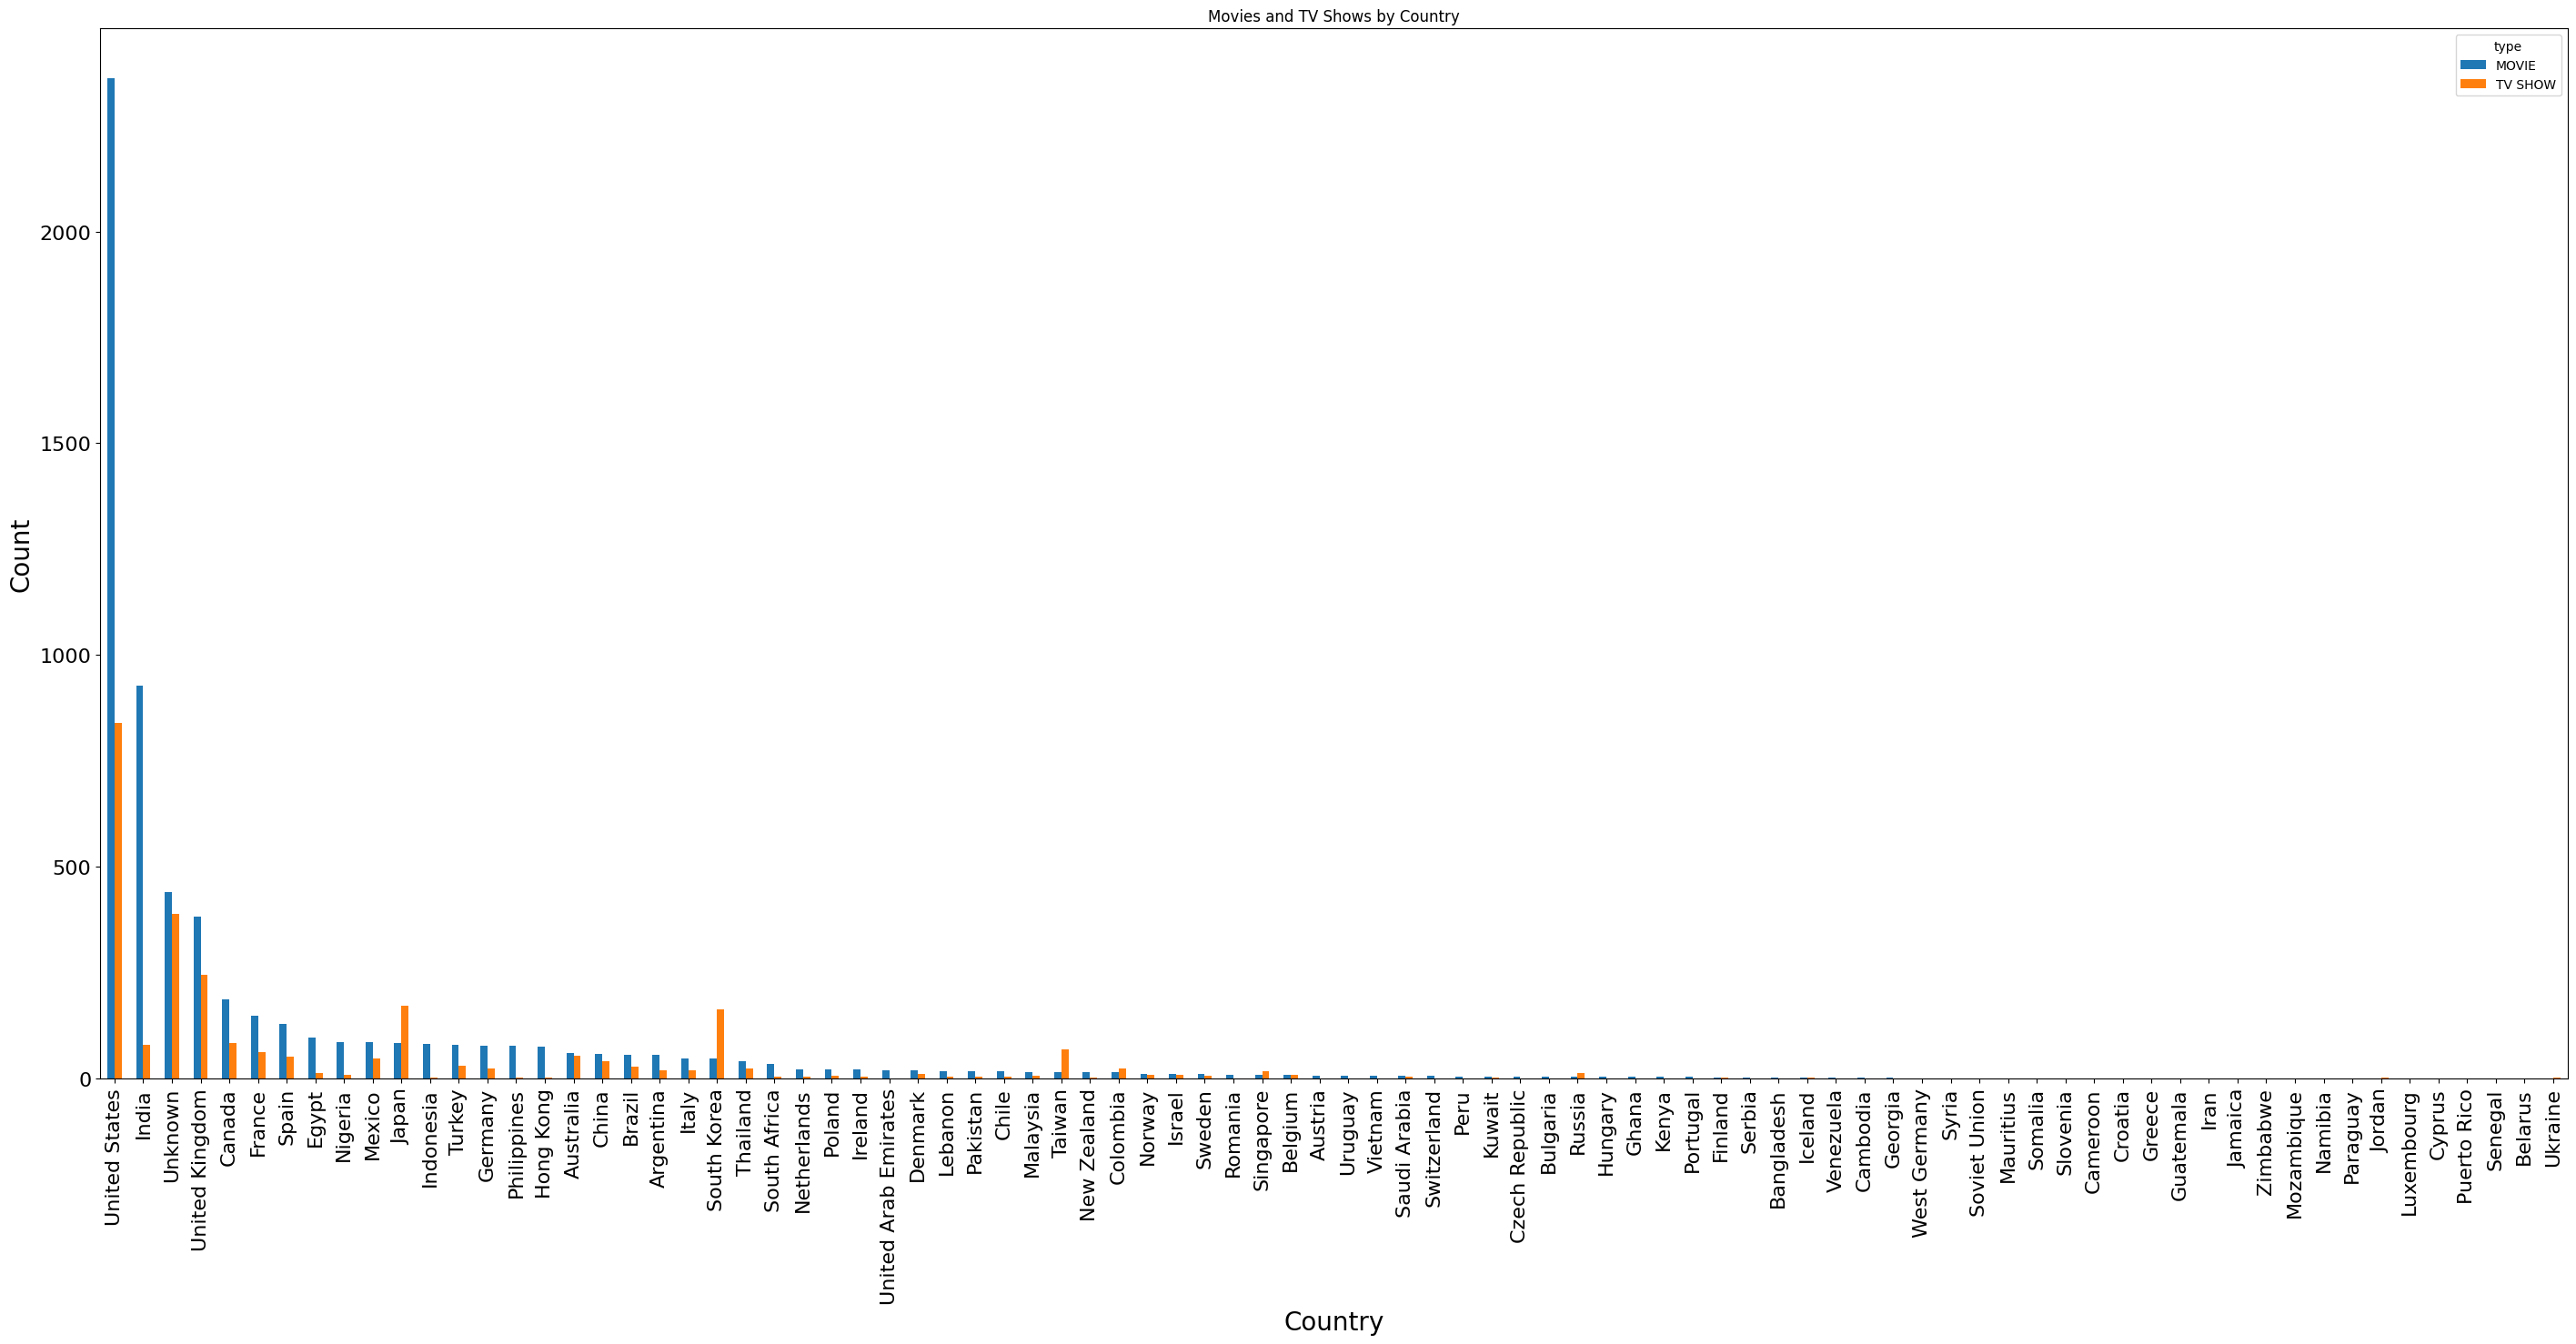

In [80]:
country_type = (netflix_cleaned.groupby(['country', 'type'])
                .size()
                .unstack(fill_value=0)
                )

# find countries with most movies
country_type.sort_values('MOVIE', ascending=False)

# find countries with most TV shows
country_type.sort_values('TV SHOW', ascending=False)

country_type.sort_values('MOVIE', ascending=False).plot(
    kind='bar',
    figsize=(35,15),
)

plt.title('Movies and TV Shows by Country')
plt.ylabel('Count', fontsize=20)
plt.xlabel('Country', fontsize=20)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.show


The chart compares the number of Movies and TV Shows produced by countries in the Netflix dataset. Most countries produce more Movies than TV Shows. The United States has the highest number of both Movies and TV Shows, while India's contribution is dominated by Movies with relatively low TV Shows. Other countries such as United Kingdom, Canada, France and Spain also produce more Movies thn TV Shows although it is varies between countries. This results indicate that Movies are the dominant type of content across most countries. This suggests that the composition of Netflix's catalog differs across countries reflecting variations in their entertainment industries and production preferences.

## Measurement of Central Tendency

### Central Tendency of Movies Duration

In [81]:
movies = netflix_cleaned[netflix_cleaned['duration_type'] == 'min']

movies_mean = movies['duration_value'].mean()
movies_median = movies['duration_value'].median()
movies_mode = movies['duration_value'].mode()[0]

movies_stats = pd.DataFrame({
    'Measure' : ['Mean', 'Median', 'Mode'],
    'Value' : [movies_mean, movies_median, movies_mode]
})

movies_stats


,Measure,Value
0,Mean,99.577187
1,Median,98.000000
2,Mode,90.000000


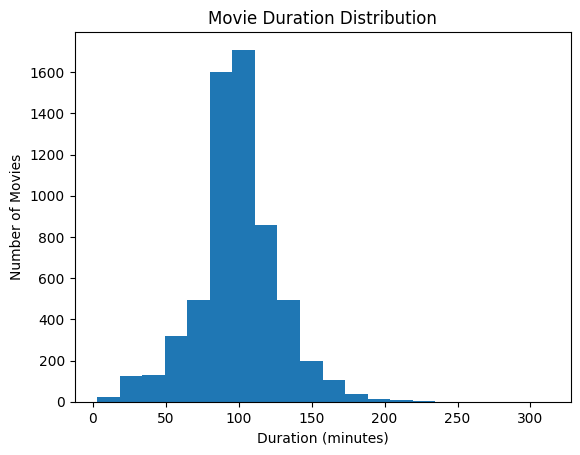

In [82]:
plt.hist(movies['duration_value'], bins=20)

plt.title('Movie Duration Distribution')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.show()

The histogram shows that most movie durations are concentrated between 80 to 120 minutes with the highest frequency occuring around 90-100 minutes. The distribution is slightly right-skewed indicating that while most movies have a similar durations, a small number of much longer movies extend the right tail of the distribution.

The mean movie duration is 99.58 minutes, the median is 98 minutes and the mode is 90 minutes. Since the mean is slightly higher than the median, the longer-duration movies increase the average duration. The median provides a better representation of a typical movie duration because it is less affected by extreme values. The mode indicates that the most common movie duration is approximate 98 mintes, which is consistent with the peak observed in the histogram.

### Central Tendency of TV Shows Duration

In [83]:
tvshows = netflix_cleaned[netflix_cleaned['duration_type'] == 'Seasons']

tvshows_mean = tvshows['duration_value'].mean()
tvshows_median = tvshows['duration_value'].median()
tvshows_mode = tvshows['duration_value'].mode()[0]

tvshows_stats = pd.DataFrame({
    'Measure' : ['Mean', 'Median', 'Mode'],
    'Value' : [tvshows_mean, tvshows_median, tvshows_mode]
})

tvshows_stats



,Measure,Value
0,Mean,3.294387
1,Median,3.000000
2,Mode,2.000000


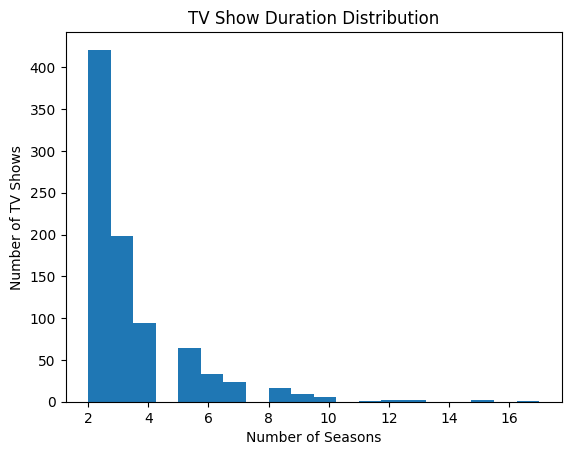

In [84]:
plt.hist(tvshows['duration_value'], bins=20)

plt.title('TV Show Duration Distribution')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')
plt.show()

The histogram shows that most TV Shows have a 2 to 3 seasons with the highest frequency occuring at 2 seasons. The distribution is strongly right-skewed, indicating that while the majority of TV Shows have relatively few seasons, a small number of long-sunning series extend the right tail of the distribution.

The mean TV Show duration is 3.29 seasons, the median is 3 seasons and the mode is 2 seasons. Since the mean is slightly higher than the median, the presence od long-running TV SHows increases the average number of seasons. The median provides a better representation of a typical TV SHow because it is less affected by these extreme values. The mode indicates that 2 seasons is the most common TV Show duration, which is consistent with the highest peak observed in the histogram.

## Measurement of Dispersion Data

### Dispersion for Movies Duration

In [117]:
movies_duration = netflix_cleaned[netflix_cleaned['duration_type'] == 'min']

movie_summary = movies_duration['duration_value'] .agg(
    Range = lambda x: x.max() - x.min(),
    Variance = 'var',
    Standard_Deviation = 'std',
    IQR = lambda x: x.quantile(0.75) - x.quantile(0.25)
).to_frame(name='Movie Duration (Minutes)')


display(movie_summary)

,Movie Duration (Minutes)
Range,309.000000
Variance,800.357678
Standard_Deviation,28.290593
IQR,27.000000


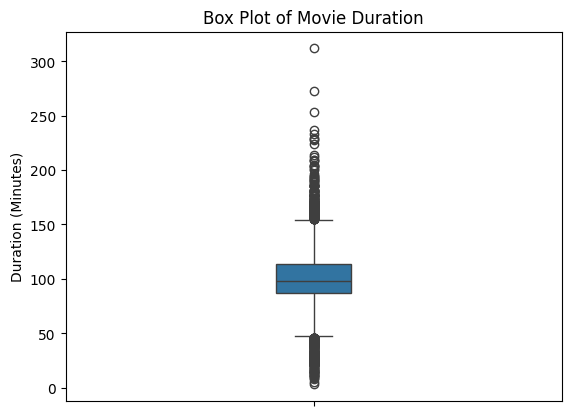

In [126]:
sns.boxplot(y="duration_value", width=0.15, data=movies_duration)

plt.title("Box Plot of Movie Duration")
plt.ylabel("Duration (Minutes)")
plt.show()

The movie duration has a range of 309 minutes, meaning there is a large difference between the shortest and longest movies. The standard deviation is 28.29 minutes, indicating that movie durations typically vary about 28 minutes from the average duration. The IQR value of 27 minutes shows that the middle 50% of movies have relatively close durations, suggesting that most movies are clustered around similiar length. However large range suggests the presence of smome extreme values or outliers, such as very long movies.

The box plot shows the distribution of movie durations in minutes. The box represents the middle of movie durations, while the whistkers show the spread of most movies. The presence of outliers indicates some movies are grouped within a smaller duration range, but a few extreme value increease the total range. 

### Dispersion for TV Shows Duration

In [121]:
TVShows_duration = netflix_cleaned[netflix_cleaned['duration_type'] == 'Seasons']

TVShows_summary = TVShows_duration['duration_value'] .agg(
    Range = lambda x: x.max() - x.min(),
    Variance = 'var',
    Standard_Deviation = 'std',
    IQR = lambda x: x.quantile(0.75) - x.quantile(0.25)
).to_frame(name='TV Shows Duration (Seasons)')


display(TVShows_summary)

,TV Shows Duration (Seasons)
Range,16.000000
Variance,2.403047
Standard_Deviation,1.550176
IQR,1.000000


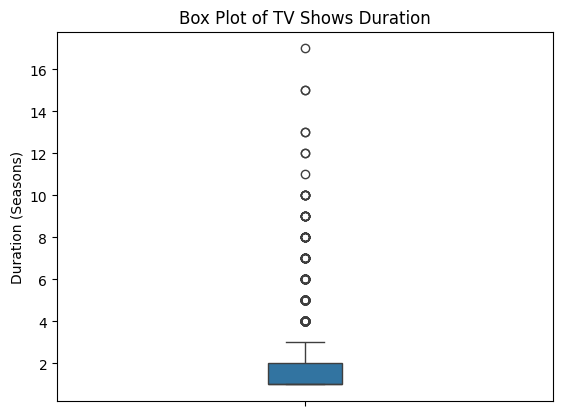

In [127]:
sns.boxplot(y="duration_value", width=0.15, data=TVShows_duration)

plt.title("Box Plot of TV Shows Duration")
plt.ylabel("Duration (Seasons)")
plt.show()

The TV show duration analysis shows a relatively low dispersion. The standard deviation of 1.55 seasons indicates that most TV shows differ from the average duration around 1 to 2 seasons. The IQR of 1 season suggest that the majority of TV shows are closely grouped together. However, the rang of 16 seasons indicates the presence of a few long-running TV hsows that increase the overall spread.

The boxplot shows that most TV shows have a similar number of seasons. The box is very small, indicating that the middle 50% of TV shows are consentrated within a narrow range. This means most TV shows do not have many seasons. Any points outside the whiskers represent outliers, which are TV shows with unusually high numbers of seasons.

## Correlation Analysis

### Corelation analysis between movie duration (hours) and release year

In [86]:
movies = netflix_cleaned[netflix_cleaned['duration_type'] == 'min']
movies['duration_hours'] = movies['duration_value']/60

# Correlation
correlation = movies[['duration_hours', 'release_year']].corr()
print(correlation)


                duration_hours  release_year
duration_hours        1.000000     -0.206285
release_year         -0.206285      1.000000


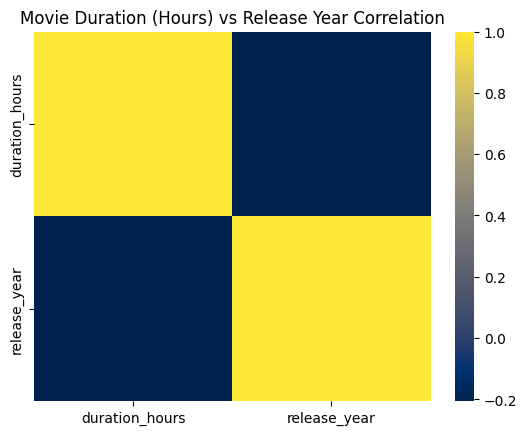

In [87]:
sns.heatmap(correlation, cmap='cividis')

plt.title("Movie Duration (Hours) vs Release Year Correlation")
plt.show()

The heatmap illustrates the correlation between movie duration (hours) and release year. The correlation coefficient is -0.206, indicating a weak negative correlation between the two variables. This siggests tha movies released in more recent years tend to have slightly shorter durations on average. However, the relationship is weak, meaning that release year has little influence on movie duration. Therefore, movie duration cannot be accurately predicted based on the release year alone, as other factors are likely to have a greater impact on the length of a movie.

## 6. Modeling / Deeper Analysis (if applicable)
- Define task (prediction, classification, clustering, inference, etc.)
- Train/test split or cross-validation
- Baselines, metrics, and parameter choices
- Control randomness with fixed seeds


## 7. Performance Evaluation and Enhancement (if applicable)

## 8. The FOUR Analytical Questions
- Answer each questions with supporting facts from the data analysis.
- Use visuals for clearer communication whenever possible. 


### Classification
Can we classify whether a Netflix title is a Movie or TV show based on duration, genre, rating and release year?


#### Section 1: Import libraries and Load Data 

In [88]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier


%matplotlib inline

# Load cleaned Netflix dataset 
df = pd.read_csv('netflix_cleaned.csv')

# Display the first few rows
display(df.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_type
0,s1,MOVIE,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,min
1,s2,TV SHOW,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,Seasons
2,s3,TV SHOW,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1,Season
3,s4,TV SHOW,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1,Season
4,s5,TV SHOW,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2,Seasons


First, we load the cleaned dataset and import related libraries. 

#### Section 2: Data Cleaning & Feature Selection

In [89]:
# Selected features.
columns_to_keep = ['type', 'release_year', 'rating', 'listed_in']
df = df[columns_to_keep].dropna()

# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Check for duplicated rows
print("\nDuplicated rows:", df.duplicated().sum())

# Drop duplicates 
df.drop_duplicates(inplace=True)
display(df.info())

Missing values:
 type            0
release_year    0
rating          0
listed_in       0
dtype: int64

Duplicated rows: 4480
<class 'pandas.DataFrame'>
Index: 4314 entries, 0 to 8791
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   type          4314 non-null   str  
 1   release_year  4314 non-null   int64
 2   rating        4314 non-null   str  
 3   listed_in     4314 non-null   str  
dtypes: int64(1), str(3)
memory usage: 168.5 KB


None

Even though the dataset is already cleaned, we need to make sure that there is no missing values and duplicated rows, to make sure that the data we give to the learning models is not corrupted. 

As you can see in the columns_to_keep variable, the 'duration' column is missing, the reason this column was discarded is to prevent data leaking. The 'duration' column's data entry for Movies are 'mins' and TV shows are 'seasons'. With this kind of information being fed to the models, it will achieve a perfect score, making it unreliable. As such, the 'duration' column was discarded.

#### Section 3: EDA

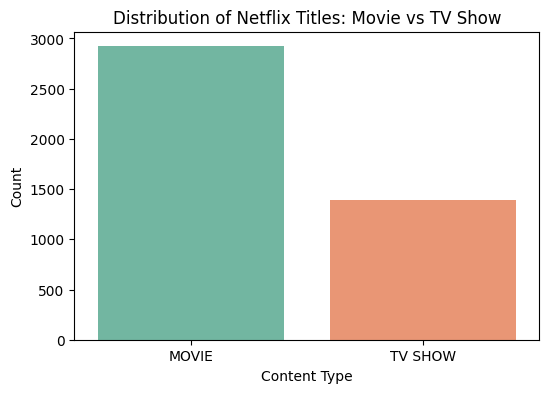

type
MOVIE      2921
TV SHOW    1393
Name: count, dtype: int64


In [90]:
# Plot the distribution of the target variable ('type')
plt.figure(figsize=(6, 4))
sns.countplot(x='type', data=df, hue='type', palette='Set2', legend=False)
plt.title('Distribution of Netflix Titles: Movie vs TV Show')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

# Print exact count
print(df['type'].value_counts())

The total count of both Movies and TV Shows are 2921 and 1393 respectively, making a grand total of 4314.

#### Section 4: Data Preprocessing

In [91]:
# Encode Target Variable: 'MOVIE' = 0, 'TV SHOW' = 1
df['type_encoded'] = df['type'].map({'MOVIE': 0, 'TV SHOW': 1})

# Encode the 'rating' column
rating_dummies = pd.get_dummies(df['rating'], prefix='rating')

# Fixing Leakage
# Must remove the words "TV" and "Movies" etc. from genre text so the model 
# has to actually learn the underlying patterns
df['clean_genres'] = df['listed_in'].str.replace('TV ', '', regex=False)\
                                    .str.replace(' Movies', '', regex=False)\
                                    .str.replace('Movies', '', regex=False)\
                                    .str.replace(' Shows', '', regex=False)

# Encode the sanitized genres
genre_dummies = df['clean_genres'].str.get_dummies(sep=', ')

# Create X and y DataFrames
X = pd.concat([df[['release_year']], rating_dummies, genre_dummies], axis=1)
y = df['type_encoded']

print("Sanitized Features shape:", X.shape)

Sanitized Features shape: (4314, 48)


**Data Preprocessing**

Data preprocessing is a step where we transform our raw data into a format the algorithm can process. For this dataset, we chose to use **One-Hot Encoding** to convert categorical text columns such as 'rating' and 'listed_in' into binary columns containing '0's and '1's.

**Data Leakage**

After runnning an initial test, we found another severe case of data leakage, which resulted in an accuracy of 99.9%. We found that in the 'listed_in' column, many genres explicitly contained our target labels within their names, (e.g., "Kids' **TV**, Horror **Movies**)

To address this issue, we introduced a sanitization step. Before one-hot encoding the genres, we used string manipulation to strip the words "TV", "Shows", and "Movies" entirely out of the dataset. This forces our model to instead learn the bahavioral patterns.

#### Section 5: Split the Data

In [92]:
# Split the data into training and testing sets (70%-30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (3019, 48)
Testing set size: (1295, 48)


We divide our dataset into a Training Set (70%) for the model to learn from, and a Testing Set (30%) to evaluate its performance.

This is done to avoid **Overfitting**. Which is an error caused by the model simply memorizing the data, rathen than learning patterns. 

**Code Breakdown:**
* `test_size=0.30`: Reserves exactly 30% of the data for the final evaluation.
* `random_state=42`: Locks the random seed. This ensures the data splits the exact same way every time the cell is run, keeping our data science pipeline **100% reproducible**.

#### Section 6: Train Classifiers

In [93]:
# Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Train Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# Train Decision Tree
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

/Users/noraliyahsyahirahbtmuhdhassanal/.pyenv/versions/3.14.0/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

Here, we feed our 70% training data (`X_train` and `y_train`) into three distinct machine learning algorithms so they can learn the rules of what makes a Netflix title a Movie versus a TV Show.

By training models from different statistical families, we can compare their performance and find the best fit for our specific problem.

* **Logistic Regression:** It calculates probabilities using linear equations.
* **Decision Tree:** A rule-based model that asks a series of Yes/No questions to split the data. It is highly interpretable but prone to overfitting (memorizing the training data).
* **Random Forest:** An "ensemble" method. It builds 100 different Decision Trees and takes a majority vote to make a final prediction. This solves the overfitting problem of a single tree and is exceptionally good at handling complex categorical data like our genres.

**Code Breakdown:**
* `model = ...`: Initializes the algorithm with our chosen settings.
* `.fit(X_train, y_train)`: The algorithm analyzes the features (`X_train`) to calculate how they map to the correct target labels (`y_train`).

#### Section 7: Evaluate Models and Visualise Confusion Matrix

=== Logistic Regression Results ===
Accuracy: 0.9204633204633205

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94       858
           1       0.99      0.77      0.87       437

    accuracy                           0.92      1295
   macro avg       0.94      0.88      0.91      1295
weighted avg       0.93      0.92      0.92      1295



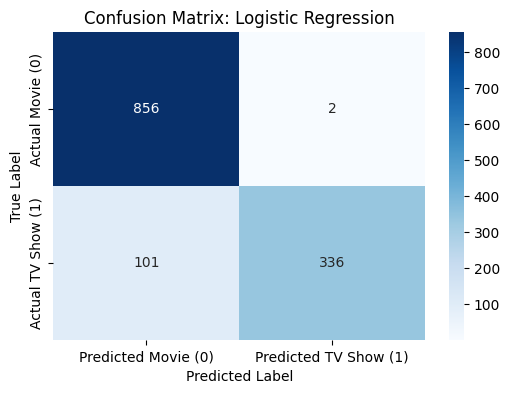


=== Random Forest Results ===
Accuracy: 0.8903474903474904

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.92       858
           1       0.86      0.81      0.83       437

    accuracy                           0.89      1295
   macro avg       0.88      0.87      0.88      1295
weighted avg       0.89      0.89      0.89      1295



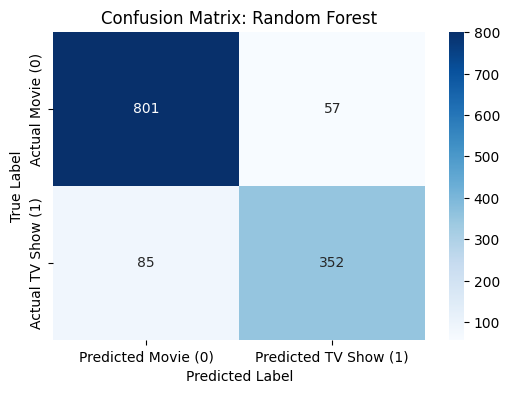


=== Decision Tree Results ===
Accuracy: 0.8872586872586873

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.92       858
           1       0.84      0.82      0.83       437

    accuracy                           0.89      1295
   macro avg       0.88      0.87      0.87      1295
weighted avg       0.89      0.89      0.89      1295



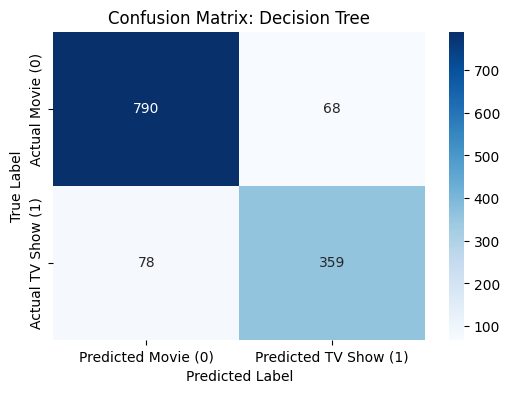

In [94]:
# Evaluate Logistic Regression 
y_pred_log = log_reg.predict(X_test)
print("=== Logistic Regression Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

# Visualize Confusion Matrix for Logistic Regression 
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Movie (0)', 'Predicted TV Show (1)'],
            yticklabels=['Actual Movie (0)', 'Actual TV Show (1)'])
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Evaluate Random Forest
y_pred_rf = rf_clf.predict(X_test)
print("\n=== Random Forest Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Visualize Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Movie (0)', 'Predicted TV Show (1)'],
            yticklabels=['Actual Movie (0)', 'Actual TV Show (1)'])
plt.title('Confusion Matrix: Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Evaluate Decision Tree 
y_pred_dt = dt_clf.predict(X_test)
print("\n=== Decision Tree Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

# Visualize Confusion Matrix for Decision Tree 
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Movie (0)', 'Predicted TV Show (1)'],
            yticklabels=['Actual Movie (0)', 'Actual TV Show (1)'])
plt.title('Confusion Matrix: Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

After training and evaluating three distinct classification models, we achieved strong, realistic predictive performance. **Logistic Regression** emerged as the most accurate model overall, achieving **92.0% accuracy**, outperforming both the Random Forest (89.0%) and the Decision Tree (88.7%). 

However, by analyzing the Classification Reports, we uncovered several crucial insights about our Netflix data:

**1. Class Imbalance Effect**
By looking at the `support` column: there are 858 Movies but only 437 TV Shows in our test set. Because there are almost twice as many movies, the Logistic Regression model became heavily biased toward guessing "Movie". 
* It achieved a perfect **Recall of 1.00** for Movies, meaning it found 100% of the movies.
* But its Recall for TV Shows dropped to **0.77** (meaning it missed 23% of the TV shows, incorrectly labeling them as Movies). 

**2. Precision vs. Recall Trade-off**
While Logistic Regression missed some TV shows, when it *did* predict a TV Show, it was almost never wrong (Precision of **0.99**). 
The Random Forest and Decision Tree models were slightly more "balanced" in how they treated both classes, but they made more overall mistakes, bringing their total accuracy down to 89%. 

**3. Tree vs. Forest**
As expected, the Random Forest (89.0%) slightly outperformed the single Decision Tree (88.7%). This proves the theory that a group of 100 trees voting together is more robust than a single tree, which is prone to memorizing the training data.

**Conclusion**
Can we predict if a Netflix title is a Movie or a TV Show based strictly on its release year, age rating, and sanitized genres? **Yes.** With 92% accuracy, Logistic Regression proves that there are strong, mathematically distinct patterns in how Netflix categorizes, rates, and assigns genres to movies versus episodic content.

## Regression
- Predict the release year of a Netflix title using its genre, rating, duration and type


In [95]:
df = pd.read_csv('netflix_cleaned.csv', encoding='latin1')

In [96]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_type
0,s1,MOVIE,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,min
1,s2,TV SHOW,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,Seasons
2,s3,TV SHOW,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1,Season
3,s4,TV SHOW,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1,Season
4,s5,TV SHOW,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2,Seasons


In [97]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_type
0,s1,MOVIE,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,min
1,s2,TV SHOW,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,Seasons
2,s3,TV SHOW,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1,Season
3,s4,TV SHOW,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1,Season
4,s5,TV SHOW,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2,Seasons


In [98]:
X = df[['type', 'rating', 'listed_in', 'duration_value']]
y = df[['release_year']]

In [99]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
type_cat = df["type"].values
type_cat_encoded = encoder.fit_transform(type_cat.astype('str'))
type_cat_encoded
df['type_cat_encoded'] = type_cat_encoded

In [100]:
#one-hot encoding for 'rating' & 'listed_in'
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, dtype=int)
rating_listed_cat = encoder.fit_transform(df[['rating', 'listed_in']])
rating_listed_cat_encoded = pd.DataFrame(rating_listed_cat, columns=encoder.get_feature_names_out(['rating', 'listed_in']))
rating_listed_cat_encoded.head()

,rating_G,rating_NC-17,rating_NR,rating_PG,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,...,"listed_in_TV Dramas, TV Sci-Fi & Fantasy, Teen TV Shows","listed_in_TV Dramas, TV Thrillers","listed_in_TV Dramas, Teen TV Shows","listed_in_TV Horror, TV Mysteries, TV Sci-Fi & Fantasy","listed_in_TV Horror, TV Mysteries, TV Thrillers","listed_in_TV Horror, TV Mysteries, Teen TV Shows","listed_in_TV Horror, Teen TV Shows","listed_in_TV Sci-Fi & Fantasy, TV Thrillers",listed_in_TV Shows,listed_in_Thrillers
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [101]:
#combine type_encoded with rating_listed_encoded and duration_value
X = pd.concat([df[['type_cat_encoded', 'duration_value']],rating_listed_cat_encoded],axis=1)
y = df['release_year']

In [102]:
X.head(15)

,type_cat_encoded,duration_value,rating_G,rating_NC-17,rating_NR,rating_PG,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,...,"listed_in_TV Dramas, TV Sci-Fi & Fantasy, Teen TV Shows","listed_in_TV Dramas, TV Thrillers","listed_in_TV Dramas, Teen TV Shows","listed_in_TV Horror, TV Mysteries, TV Sci-Fi & Fantasy","listed_in_TV Horror, TV Mysteries, TV Thrillers","listed_in_TV Horror, TV Mysteries, Teen TV Shows","listed_in_TV Horror, Teen TV Shows","listed_in_TV Sci-Fi & Fantasy, TV Thrillers",listed_in_TV Shows,listed_in_Thrillers
0,0,90,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,91,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,125,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,1,9,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
9,0,104,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [103]:
y.head()

0    2020
1    2021
2    2021
3    2021
4    2021
Name: release_year, dtype: int64

In [104]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [105]:
# check shapes after splitting
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(6595, 529)
(6595,)
(2199, 529)
(2199,)


In [106]:
from sklearn.linear_model import LinearRegression

In [107]:
model = LinearRegression().fit(X_train, y_train)

In [108]:
y_pred = model.predict(X_test)

In [109]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [110]:
#get r2 coefficient
r2 = model.score(X_test, y_test)
print("R² score:", r2)

#get MAE
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

#get MSE
mse = np.sqrt(mean_squared_error(y_test, y_pred))
print("MSE:", mse)

R² score: 0.34949253597067875
MAE: 4.2700993914657115
MSE: 6.912713420448925


In [111]:
#predictions
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(results.head())

      Actual    Predicted
3092    2019  2018.454681
4079    2018  2017.306728
4892    2015  2016.093330
4589    2018  2018.108021
5317    2017  2014.146904


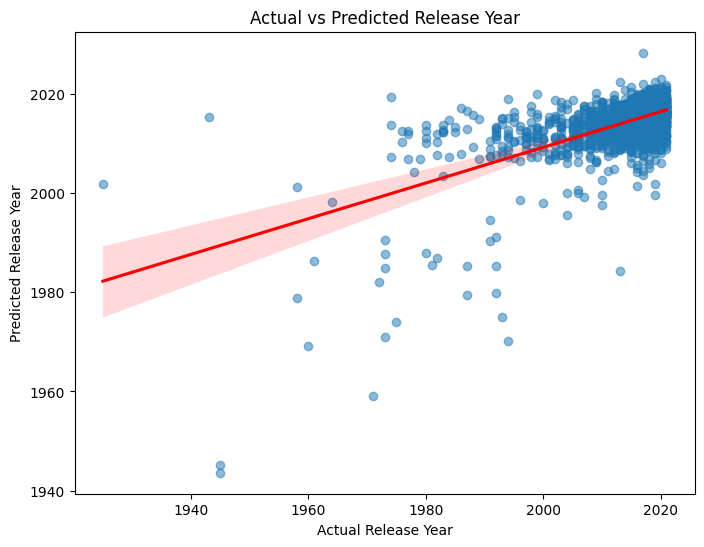

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.regplot(
    x=y_test,
    y=y_pred,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)

plt.xlabel("Actual Release Year")
plt.ylabel("Predicted Release Year")
plt.title("Actual vs Predicted Release Year")

plt.show()

Scatter plot shows the relationship between actual and predicted release years generated by the Linear Regression model. The model shows a positive trend indicating that it demonstrates better predictive performance for titles released in the year 2000-2020. However, it has a harder time capturing patterns from older titles due to limited number of older titles present in the dataset.

## 9. Results & Interpretation
- Summarize key findings
- Discuss insights generated from the data analysis and modeling
- Present the most informative visuals/tables with clear captions
- Relate results back to the research questions


### Regression
1. The Linear Regression model achieved an R² score of 0.349 indicating that approximately 34.9% of the variation in release year can be explained by the chosen variables.
2. This model also has a MAE of 4.27 meaning that predicted release years differ from actual release years by an average of 4 years.
3. It captures a better prediction from titles released in the year 2000-2020 compared to movies/TV shows released prior to 2000.

## 10. Conclusions & Limitations
- What did you learn?
- What are limitations and possible biases?
- What are logical next steps or improvements?


### Regression
- The limitiations I experienced is that the model has a more accurate prediction for titles released in the year 2000-2020. This is mainly because the dataset lacks titles that were released prior to 2000 which can affect the model's accuracy. The best step to improve my model is to remove the outliers which are movie/TV shows that were released prior to the 2000s. This can reduce my errors significantly and give me a better R² score.  

## References
- Any academic articles, blogs, or documentation used
- All references in APA format only
- Citation in text example: The field of natural language processing has become dominated by deep learning approaches (Young et al., [2018](https://doi.org/10.1109/MCI.2018.2840738)).
- Citation example in the list:
    - [Python Docs](https://docs.python.org/3/)
    - [Python Tutorial](https://docs.python.org/3/tutorial/index.html)



## Academic Integrity

- Work must be your own. If you use code snippets or ideas from references, cite them in the notebook.
- Do not include copyrighted data not permitted for redistribution.


## Plagiarism
It is fine to seek help from friends or from online resources when you do the assignment, However,
seeking help should not go overboard, to the point of getting (or even paying) someone to
complete the assignment partly or fully for you, copying from online resources without
understanding, or doing any means with the intention to cheat. 

For this assignment, plagiarism
means the following:
(a) Turning in a work that, from the examiner’s point of view, you do not sufficiently understand.
(b) Turning in someone else’s work (whether partly or fully) as your own.
(c) To use another’s work (whether partly or fully) without crediting the source.
(d) Any means of cheating.

**Plagiarism is a serious offence.**

**We will give ZERO (0) marks to students who plagiarize AND to students who intentionally or
unintentionally help other students to plagiarize by giving all or some of their code.**

## Final Self‑Checklist (before submitting)

* [ ] Rename your Jupyter Notebook file according to your group number
* [ ] All items in README section are filled up
* [ ] All group members' ID, name, and contribution fill-in.
* [ ] Dataset link is from a recognized source and publicly accessible
* [ ] YouTube link is accessible.
* [ ] Notebook runs end‑to‑end with no manual steps beyond placing data files
* [ ] Dataset loaded once only
* [ ] No absolute paths; only relative paths used
* [ ] All figures have titles/labels; text and tables are readable
* [ ] Methods and choices are explained and justified
* [ ] References properly cited
* [ ] Notebook is clear, professional, and run within reasonable runtime